In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d

from scipy.fft import rfft, rfftfreq, irfft
from scipy.fft import fft, fftfreq

from astropy.table import Table


In [15]:
def apply_redshift(w,f,z):
    wz = w * (1.+z)
    fz = f / (1.+z)
    return wz,fz

In [16]:
# SDSS spectra

In [17]:
# galaxy spectrum
dat = Table.read('../spec-0285-51930-0495.fits', format='fits')
sdss_g = dat.to_pandas()

In [18]:
# Read star spectrum
dat = Table.read('../spec-2917-54556-0283.fits', format='fits')
sdss_s = dat.to_pandas()

(3850.0, 9000.0)

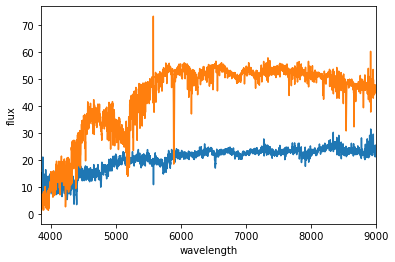

In [19]:
# Plot
plt.plot(np.power(10.,sdss_g['loglam']),sdss_g['flux'])
plt.plot(np.power(10.,sdss_s['loglam']),sdss_s['flux'])
plt.xlabel('wavelength')
plt.ylabel('flux')
plt.xlim(3850.,9000.)


(4200.0, 4500.0)

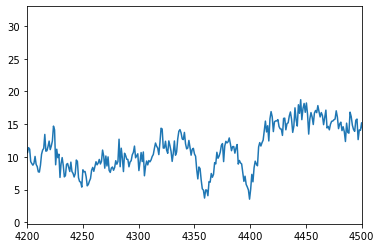

In [79]:
plt.plot(np.power(10.,sdss_g['loglam']),sdss_g['flux'])
plt.xlim(4200.,4500.)


In [20]:
# smooth
fl_g_g = gaussian_filter(np.array(sdss_g['flux']),201)
fl_s_g = gaussian_filter(np.array(sdss_s['flux']),201)



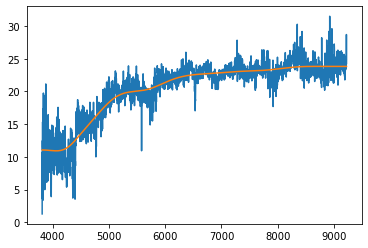

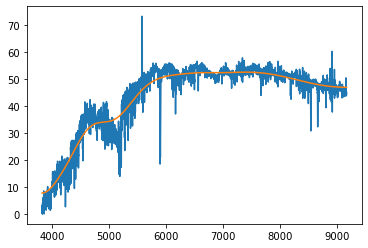

In [21]:
plt.plot(np.power(10.,sdss_g['loglam']),sdss_g['flux'])
plt.plot(np.power(10.,sdss_g['loglam']),fl_g_g)
plt.figure()
plt.plot(np.power(10.,sdss_s['loglam']),sdss_s['flux'])
plt.plot(np.power(10.,sdss_s['loglam']),fl_s_g)


In [22]:
fl_g_gd = sdss_g['flux'] - fl_g_g
std_g = np.std(fl_g_gd)
fl_g_gdn = fl_g_gd / std_g

fl_s_gd = sdss_s['flux'] - fl_s_g
std_s = np.std(fl_s_gd)
fl_s_gdn = fl_s_gd / std_s


In [23]:
w_g = np.power(10.,sdss_g['loglam'])
w_s = np.power(10.,sdss_s['loglam'])

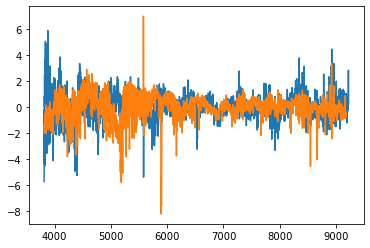

In [24]:
plt.plot(w_g,fl_g_gdn)
plt.plot(w_s,fl_s_gdn)

In [25]:
# interpolator
g_interp = interp1d(w_g,fl_g_gdn)
s_interp = interp1d(w_s,fl_s_gdn)

In [26]:
w1 = max(np.amin(w_g),np.amin(w_s)) 
w2 = min(np.amax(w_s),np.amax(w_s))
print (w1,w2)

3818.562255859375 9172.76171875


In [30]:
ww1 = w1 + 0.1
ww2 = w2 - 0.1

CPU times: user 1.1 s, sys: 10.4 ms, total: 1.11 s
Wall time: 1.11 s


Text(0, 0.5, 'CCF')

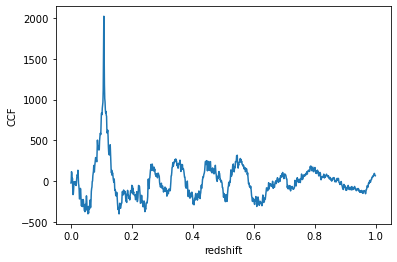

In [33]:
%%time
# star spectrum (smooth-subtracted-normalised)
# w_s,fl_s_gdn
# gal spectrum
# w_g,fl_g_gdn

nn = 1000
ccfn = np.ndarray(shape=(nn))
z = np.ndarray(shape=(nn))
for i in range(nn):
    z[i] = i*(1./nn)
    wsz = w_s * (1.+z[i])
    fsz = fl_s_gdn / (1.+z[i])
    
    wj1 = max(np.amin(wsz),ww1) + 0.1
    wj2 = min(np.amax(wsz),ww2) - 0.1
        
    dwc = 1.0
    w_int = np.linspace(wj1,wj2,int((wj2-wj1)/dwc))

    galinterp = interp1d(w_g,fl_g_gdn)
    starinterp = interp1d(wsz,fsz)
    
    gal_spec = galinterp(w_int)
    star_spec = starinterp(w_int)
    
    ccfn[i] = np.sum(gal_spec*star_spec)
    
plt.plot(z,ccfn)        
plt.xlabel('redshift')
plt.ylabel('CCF')

z = 0.108


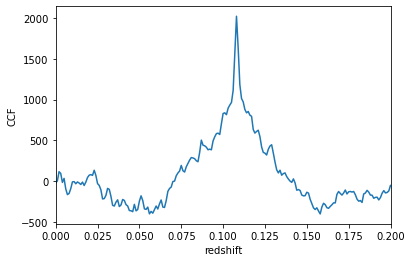

In [39]:
plt.plot(z,ccfn)        
plt.xlabel('redshift')
plt.ylabel('CCF')
plt.xlim(0.0,0.2)
print ('z =',z[np.argmax(ccfn)])